<a href="https://colab.research.google.com/github/fabricejumel/https-github.com-fabricejumel-4ETI_IMI_20252026-AI/blob/main/classification/CIFAR10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### F. JUMEL

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

In [2]:
#@title MIT License
#
# Copyright (c) 2017 François Chollet
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Basic classification: Classify images from CIFAR10

This guide trains a neural network model to classify different images

This guide uses [tf.keras](https://www.tensorflow.org/guide/keras), a high-level API to build and train models in TensorFlow.

In [3]:
# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.19.0


## Import the CIFAR10  dataset

In [4]:
cifar10 = tf.keras.datasets.cifar10

(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 34s 0us/step


Loading the dataset returns four NumPy arrays:

* The `train_images` and `train_labels` arrays are the *training set*—the data the model uses to learn.
* The model is tested against the *test set*, the `test_images`, and `test_labels` arrays.

The images are 32x32x3 NumPy arrays, with pixel values ranging from 0 to 255 (representing RGB channels).
The labels are an array of integers, ranging from 0 to 9, corresponding to the 10 classes in the CIFAR-10 dataset.

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [5]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

## Explore the data

Let's explore the format of the dataset before training the model. The following shows there are 50,000 images in the training set, with each image represented as 32 x 32 pixels:

In [6]:
train_images.shape

(50000, 32, 32, 3)

Likewise, there are 60,000 labels in the training set:

In [7]:
len(train_labels)

50000

Each label is an integer between 0 and 9:

In [8]:
train_labels

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

There are 10,000 images in the test set. Again, each image is represented as 32 x 32 pixels with 3 channels (R,G,B):

In [9]:
test_images.shape

(10000, 32, 32, 3)

And the test set contains 10,000 images labels:

In [10]:
len(test_labels)

10000

## Preprocess the data

The data must be preprocessed before training the network. If you inspect the first image in the training set, you will see that the pixel values fall in the range of 0 to 255 on each channel:

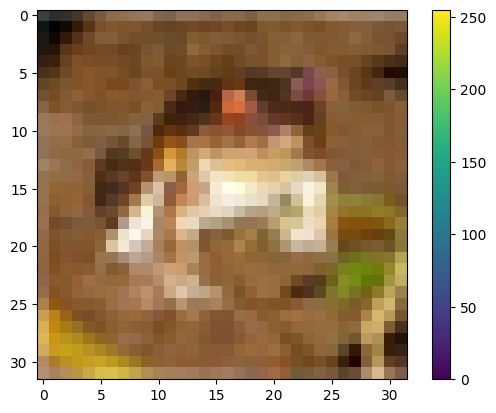

In [11]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the *training set* and the *testing set* be preprocessed in the same way:

In [12]:
train_images = train_images / 255.0

test_images = test_images / 255.0

To verify that the data is in the correct format and that you're ready to build and train the network, let's display the first 25 images from the *training set* and display the class name below each image.

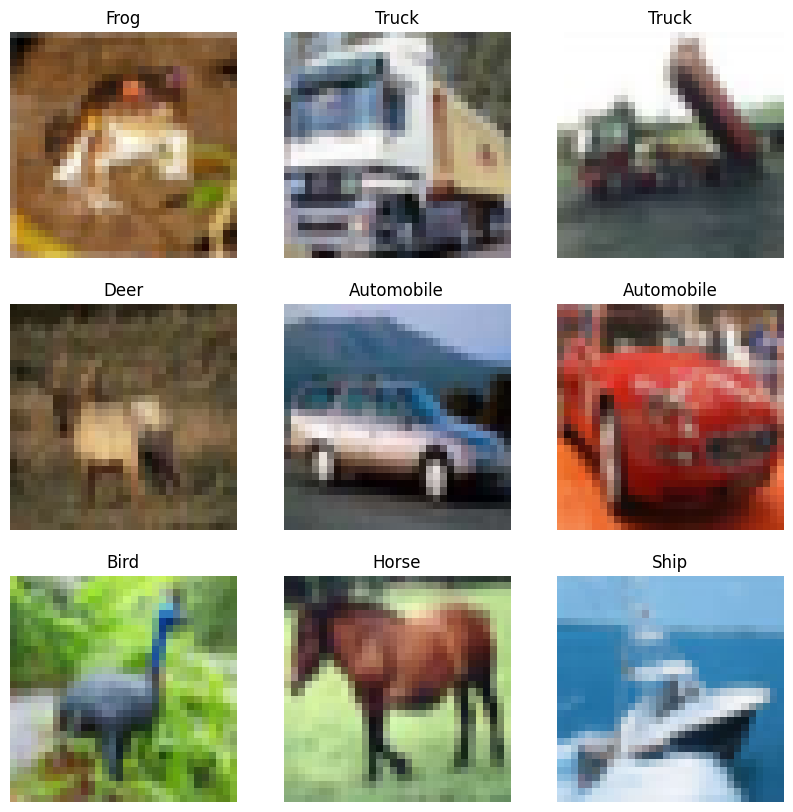

In [13]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')
plt.show()

## Build the model

Building the neural network requires configuring the layers of the model, then compiling the model.

### Set up the layers

The basic building block of a neural network is the [*layer*](https://www.tensorflow.org/api_docs/python/tf/keras/layers). Layers extract representations from the data fed into them. Hopefully, these representations are meaningful for the problem at hand.

Most of deep learning consists of chaining together simple layers. Most layers, such as `tf.keras.layers.Dense`, have parameters that are learned during training.

In [14]:
def create_simplest_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(10)
    ], name="Simplest_NN_CIFAR10_Model")
    return model

def create_vanilla_nn_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10)
    ], name="Vanilla_NN_CIFAR10_Model")
    return model

def create_lenet5_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Conv2D(6, kernel_size=(5, 5), activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(16, kernel_size=(5, 5), activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10)
    ], name="Lenet5_CIFAR10_Model")
    return model

def create_vanilla_cnn_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10)
    ], name="Vanilla_CNN_CIFAR10_Model")
    return model

def create_alexnet_cifar10_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),  # Ajout de la couche d'entrée
        tf.keras.layers.Conv2D(96, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        tf.keras.layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        tf.keras.layers.Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(384, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10)
    ], name="AlexNet_CIFAR10_Model")
    return model

# Créer les modèles
model_simplest = create_simplest_cifar10_model()
model_vanilla_nn = create_vanilla_nn_cifar10_model()
model_lenet5 = create_lenet5_cifar10_model()
model_vanilla_cnn = create_vanilla_cnn_cifar10_model()
model_alexnet = create_alexnet_cifar10_model()

# Afficher le résumé d'un modèle
model = model_alexnet
model.summary()


Model: "AlexNet_CIFAR10_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,930,826 (140.88 MB)

 Trainable params: 36,928,074 (140.87 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False, name='Adam'),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

## Train the model

Training the neural network model requires the following steps:

1. Feed the training data to the model. In this example, the training data is in the `train_images` and `train_labels` arrays.
2. The model learns to associate images and labels.
3. You ask the model to make predictions about a test set—in this example, the `test_images` array.
4. Verify that the predictions match the labels from the `test_labels` array.


### Feed the model

To start training,  call the [`model.fit`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit) method—so called because it "fits" the model to the training data:

In [16]:
model.fit(
    train_images,  # Training images
    train_labels,  # Corresponding labels
    batch_size=32,  # Default batch size, meaning the number of samples processed before a model update
    epochs=10,  # Number of epochs (full passes over the dataset)
    verbose=1,  # Verbosity level (1 = displays training progress)
    validation_split=0.0,  # No validation set is generated from the training data
    shuffle=True,  # Shuffles the training data before each epoch
    callbacks=None  # No callbacks are used for specific actions during training
)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 25ms/step - accuracy: 0.4059 - loss: 1.8812
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5530 - loss: 1.3203
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6570 - loss: 1.0285
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7293 - loss: 0.8142
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7793 - loss: 0.6665
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.8225 - loss: 0.5393
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.8508 - loss: 0.4513
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.8766 - loss: 0.3732
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.8952 - loss: 0.3173
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.9115 - loss: 0.2722


### Evaluate accuracy

Next, compare how the model performs on the test dataset:

In [17]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 5s - 16ms/step - accuracy: 0.7567 - loss: 0.8763

Test accuracy: 0.7566999793052673


It turns out that the accuracy on the test dataset is a little less than the accuracy on the training dataset. This gap between training accuracy and test accuracy represents *overfitting*. Overfitting happens when a machine learning model performs worse on new, previously unseen inputs than it does on the training data. An overfitted model "memorizes" the noise and details in the training dataset to a point where it negatively impacts the performance of the model on the new data. For more information, see the following:
*   [Demonstrate overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit#demonstrate_overfitting)
*   [Strategies to prevent overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit#strategies_to_prevent_overfitting)

### Make predictions

With the model trained, you can use it to make predictions about some images.
Attach a softmax layer to convert the model's linear outputs—[logits](https://developers.google.com/machine-learning/glossary#logits)—to probabilities, which should be easier to interpret. Rq: Its classical to add directly the softmax in the output of the model (tf.keras.layers.Dense(10, activation='softmax') but in this case change from_logits=True to from_logits=False  )

In [18]:
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

In [19]:
predictions = probability_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


Here, the model has predicted the label for each image in the testing set. Let's take a look at the first prediction:

In [20]:
predictions[0]

array([3.5921810e-05, 3.1868844e-05, 9.2432869e-04, 9.9341303e-01,
       5.6894094e-04, 4.0166383e-03, 5.8417447e-04, 3.3977747e-04,
       6.2269137e-05, 2.3063149e-05], dtype=float32)

A prediction is an array of 10 numbers. They represent the model's "confidence" that the image corresponds to each of the 10 different articles of clothing. You can see which label has the highest confidence value:

In [21]:
np.argmax(predictions[0])

np.int64(3)

So, the model is most confident that this image is an ankle boot, or `class_names[9]`. Examining the test label shows that this classification is correct:

In [22]:
test_labels[0].item()

3

Define functions to graph the full set of 10 class predictions.

In [23]:
def plot_image(i, predictions_array, true_label, img):
    true_label = test_labels[i].item()  # Extraire le label vrai pour l'index i
    plt.imshow(img[i], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)  # Prendre le label prédit
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100*np.max(predictions_array),
                                         class_names[true_label]),  # Utiliser true_label directement
               color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i].item()
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

### Verify predictions

With the model trained, you can use it to make predictions about some images.

Let's look at the 0th image, predictions, and prediction array. Correct prediction labels are blue and incorrect prediction labels are red. The number gives the percentage (out of 100) for the predicted label.

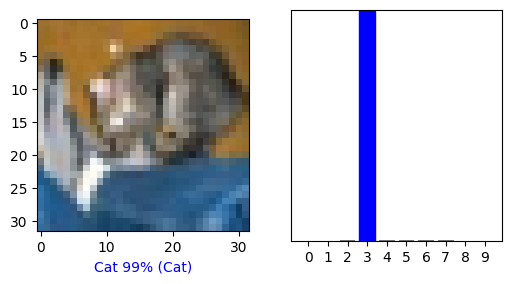

In [24]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

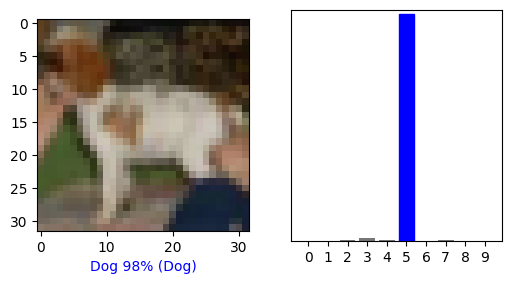

In [25]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

Let's plot several images with their predictions. Note that the model can be wrong even when very confident.

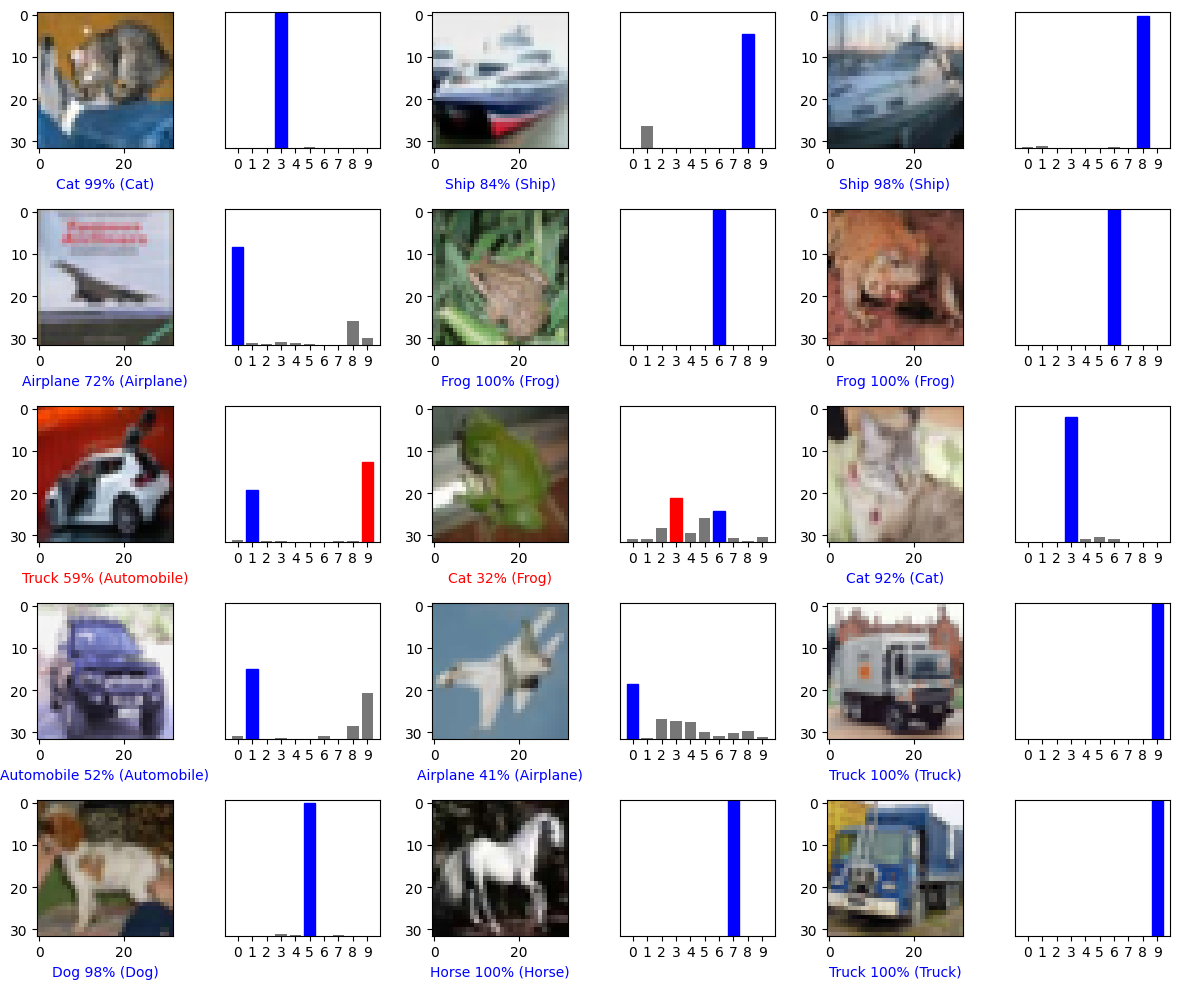

In [26]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

## Use the trained model

Finally, use the trained model to make a prediction about a single image.

In [27]:
# Grab an image from the test dataset.
img = test_images[1]

print(img.shape)

(32, 32, 3)


`tf.keras` models are optimized to make predictions on a *batch*, or collection, of examples at once. Accordingly, even though you're using a single image, you need to add it to a list:

In [28]:
# Add the image to a batch where it's the only member.
img = (np.expand_dims(img, 0))

print(img.shape)

(1, 32, 32, 3)


Now predict the correct label for this image:

In [29]:
predictions_single = probability_model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 975ms/step
[[1.5194385e-04 1.5984130e-01 8.1552116e-09 2.4193969e-08 9.6031502e-11
  4.1142751e-09 1.5630198e-07 1.1300615e-09 8.3979750e-01 2.0899238e-04]]


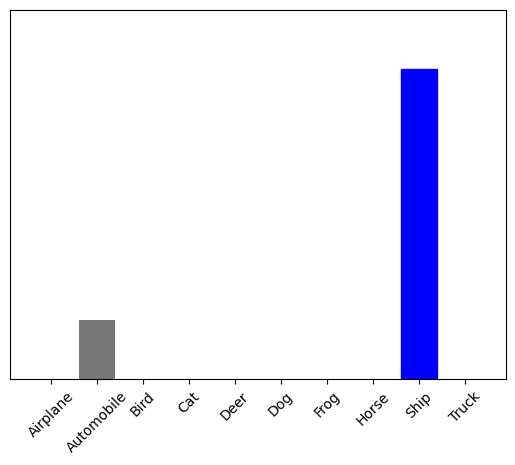

In [30]:
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)
plt.show()

`tf.keras.Model.predict` returns a list of lists—one list for each image in the batch of data. Grab the predictions for our (only) image in the batch:

In [31]:
np.argmax(predictions_single[0])

np.int64(8)

And the model predicts a label as expected.

To learn more about building models with Keras, see the [Keras guides](https://www.tensorflow.org/guide/keras).

## Matrix Confusion
### Check the consistency of the test dataset.
 As we will use percentages next, first ensure that the test dataset is homogeneous

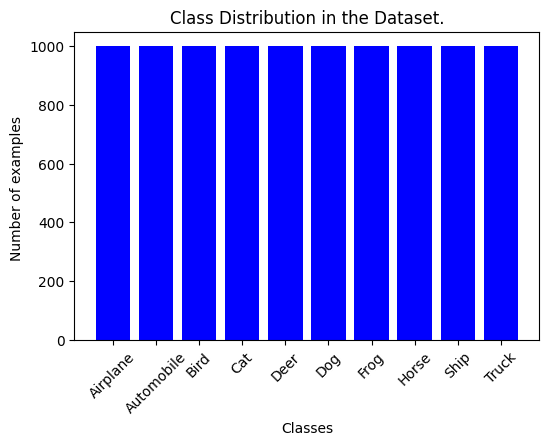

In [32]:
def plot_class_distribution(labels, class_names):
    # Convertir les labels en un tableau 1D si nécessaire
    labels_flat = labels.flatten()

    # Compter les occurrences de chaque classe
    class_counts = np.bincount(labels_flat)

    # Affichage de la répartition des classes
    plt.figure(figsize=(6, 4))
    plt.bar(class_names, class_counts, color='blue')
    plt.xlabel('Classes')
    plt.ylabel('Number of examples ')
    plt.title('Class Distribution in the Dataset.')
    plt.xticks(rotation=45)
    plt.show()
plot_class_distribution(test_labels, class_names)


### Confusion Matrix


A confusion matrix is a powerful tool used to evaluate the performance of a classification model. It provides a summary of the prediction results, comparing the actual labels with the predicted labels. In this context, particularly when working with a model for image classification (like CIFAR-10), the confusion matrix helps us understand how well the model distinguishes between different classes.

Each row of the matrix represents the instances of an actual class, while each column represents the instances of a predicted class. The diagonal elements indicate the number of correct predictions for each class, while the off-diagonal elements represent misclassifications.

By converting the counts in the confusion matrix to percentages, we can gain deeper insights into the model's performance, allowing us to identify which classes are often confused with one another. This analysis is crucial for improving the model's accuracy and making informed decisions about further training or adjustments needed to enhance classification performance.

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


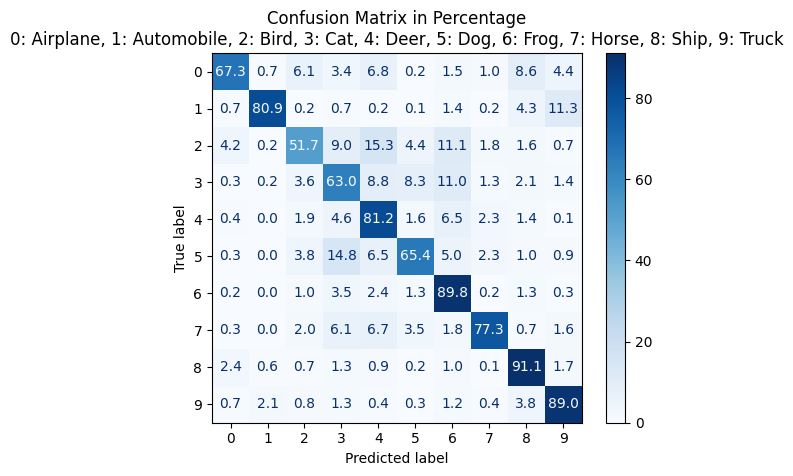

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Prédictions avec le modèle
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

# Calculer la matrice de confusion et la normaliser en pourcentage
cm = confusion_matrix(test_labels, predicted_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # Convertir en pourcentages

# Afficher la matrice de confusion normalisée
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues, values_format=".1f")  # Afficher les pourcentages avec 2 décimales

# Légende  classes

class_list = ", ".join([f"{i}: {class_name}" for i, class_name in enumerate(class_names)])
plt.title(f'Confusion Matrix in Percentage\n{class_list}')

plt.show()


## Explicabilite des resultats

L'objectif ici n'est pas seulement de connaitre la classe predite, mais de verifier **sur quelles zones de l'image** le modele s'appuie. C'est utile pour detecter un comportement incoherent, par exemple si le reseau se focalise sur le fond plutot que sur l'objet.

Le code qui suit n'utilise pas GradCAM++ mais **Integrated Gradients**. C'est une methode d'attribution qui mesure la contribution de chaque pixel a la prediction. Elle est compatible avec un reseau dense comme avec un CNN.

GradCAM++ reste cependant tres pertinent pour un **CNN**, car il exploite les cartes de caracteristiques convolutionnelles pour produire une heatmap spatiale plus intuitive. Sur un reseau dense pur, cette lecture spatiale est moins naturelle, ce qui rend Integrated Gradients plus defendable pour le modele actuellement entraine dans ce notebook.

Autres options pertinentes selon l'objectif: `GradCAM++` sur `model_vanilla_cnn` ou `model_alexnet` pour une lecture spatiale directe, `occlusion sensitivity` pour tester l'impact de chaque patch de l'image, et `SHAP` si vous voulez une analyse plus formelle mais plus couteuse.

### Petit rapport d'interprétation

Pour un CNN, une heatmap doit montrer les zones de l'image qui ont réellement servi à la décision. Si la carte se concentre sur l'objet principal, l'explication est cohérente. Si elle se disperse sur le fond ou les bords, cela suggère que le modèle exploite des indices parasites.

Avec GradCAM++, on lit une importance spatiale des régions convolutionnelles, ce qui est naturel pour un CNN. Avec Integrated Gradients, on lit plutôt la contribution des pixels à la prédiction finale. Les deux approches sont utiles, mais GradCAM++ est en général plus visuel pour un CNN, alors qu'Integrated Gradients reste plus general et plus simple à appliquer à plusieurs types de modèles.

Dans ce notebook, le modèle actuellement entraîné est un réseau dense. Le choix d'Integrated Gradients est donc coherent. Si l'on compare ensuite avec un CNN comme `model_vanilla_cnn` ou `model_alexnet`, GradCAM++ devient un très bon complément pour vérifier où le CNN concentre son attention.

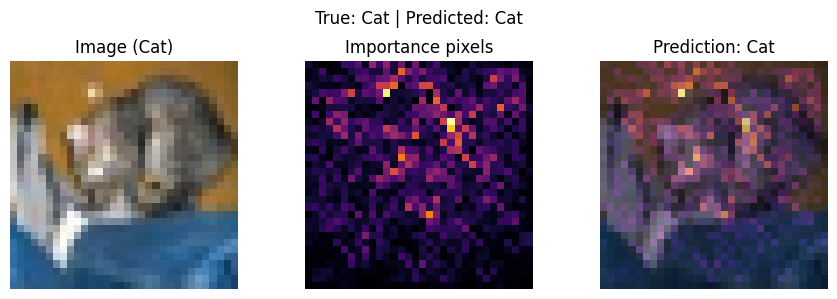

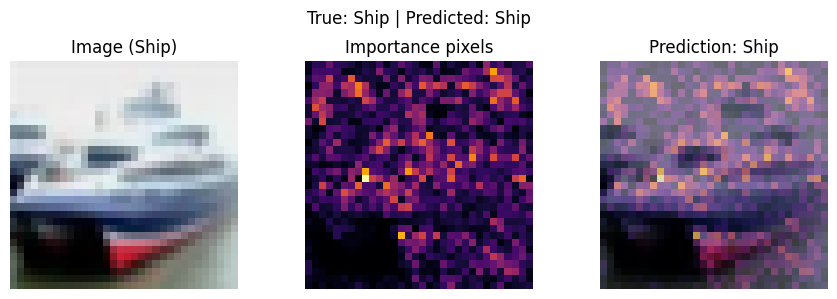

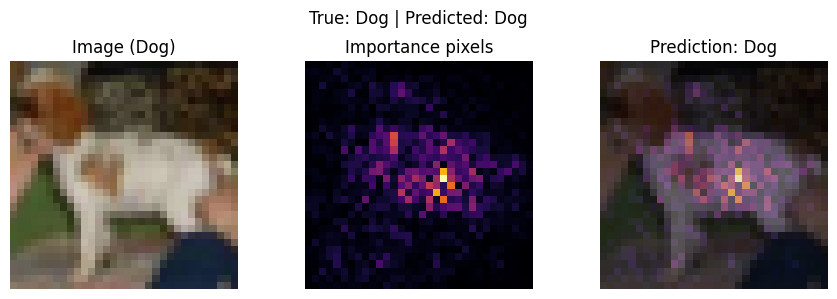

In [34]:
# Explicabilite modele-agnostique pour le modele actuellement entraine dans le notebook
# Cette approche est plus pertinente ici que GradCAM++ si le modele reste un reseau dense.

def integrated_gradients(image, target_class_idx, baseline=None, steps=32):
    image = tf.cast(image, tf.float32)
    if baseline is None:
        baseline = tf.zeros_like(image)
    else:
        baseline = tf.cast(baseline, tf.float32)

    alphas = tf.linspace(0.0, 1.0, steps + 1)
    interpolated = baseline[tf.newaxis, ...] + alphas[:, tf.newaxis, tf.newaxis, tf.newaxis] * (image - baseline)[tf.newaxis, ...]

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        predictions = model(interpolated)
        target_scores = predictions[:, target_class_idx]

    gradients = tape.gradient(target_scores, interpolated)
    average_gradients = (gradients[:-1] + gradients[1:]) / 2.0
    integrated_grads = (image - baseline) * tf.reduce_mean(average_gradients, axis=0)
    return integrated_grads

def explain_image(index, baseline=None, steps=32):
    image = tf.cast(test_images[index], tf.float32)
    true_label = int(test_labels[index].item())
    logits = model(tf.expand_dims(image, axis=0))
    predicted_label = int(tf.argmax(logits[0]).numpy())

    attributions = integrated_gradients(image, predicted_label, baseline=baseline, steps=steps)
    saliency = tf.reduce_sum(tf.abs(attributions), axis=-1)
    saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency) + 1e-8)

    plt.figure(figsize=(9, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title(f'Image ({class_names[true_label]})')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(saliency.numpy(), cmap='inferno')
    plt.title('Importance pixels')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(image)
    plt.imshow(saliency.numpy(), cmap='inferno', alpha=0.55)
    plt.title(f'Prediction: {class_names[predicted_label]}')
    plt.axis('off')

    plt.suptitle(f'True: {class_names[true_label]} | Predicted: {class_names[predicted_label]}')
    plt.tight_layout()
    plt.show()

for index in [0, 1, 12]:
    explain_image(index)


Image : Cat


/tmp/ipykernel_3381/3290996839.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = class_names[int(test_labels[0])]


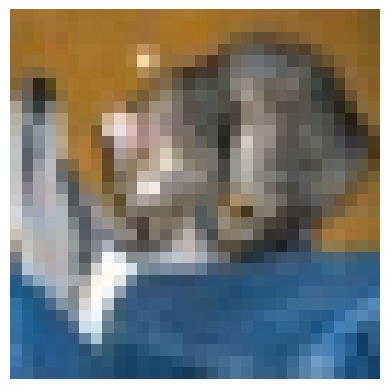

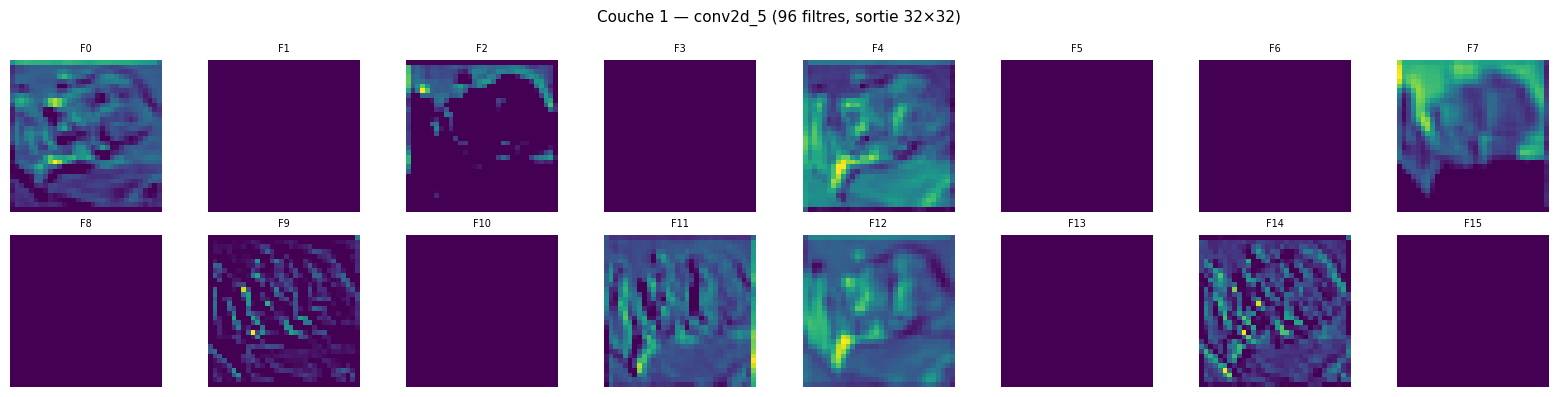

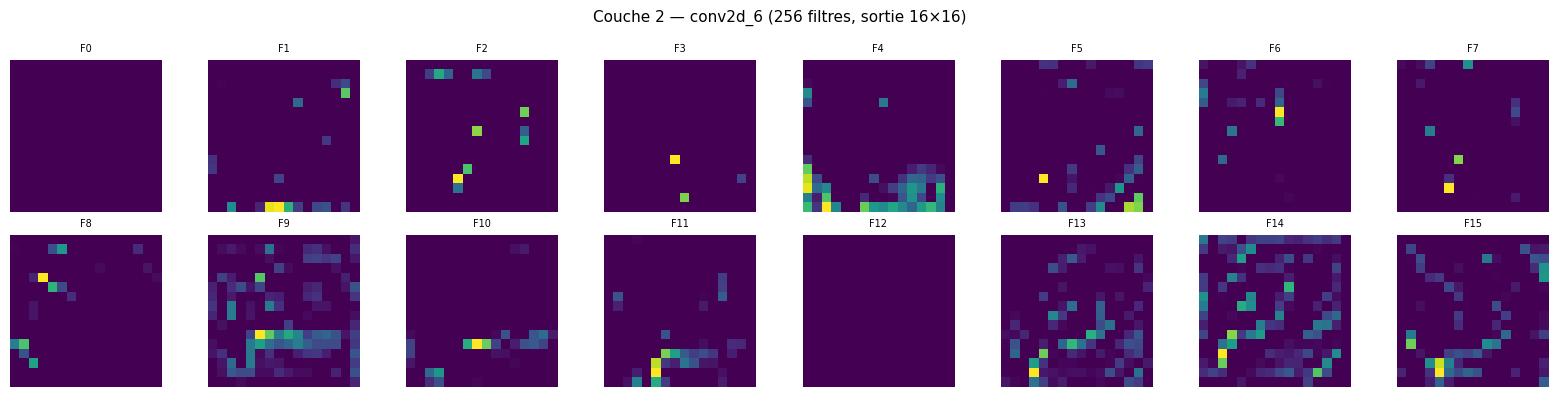

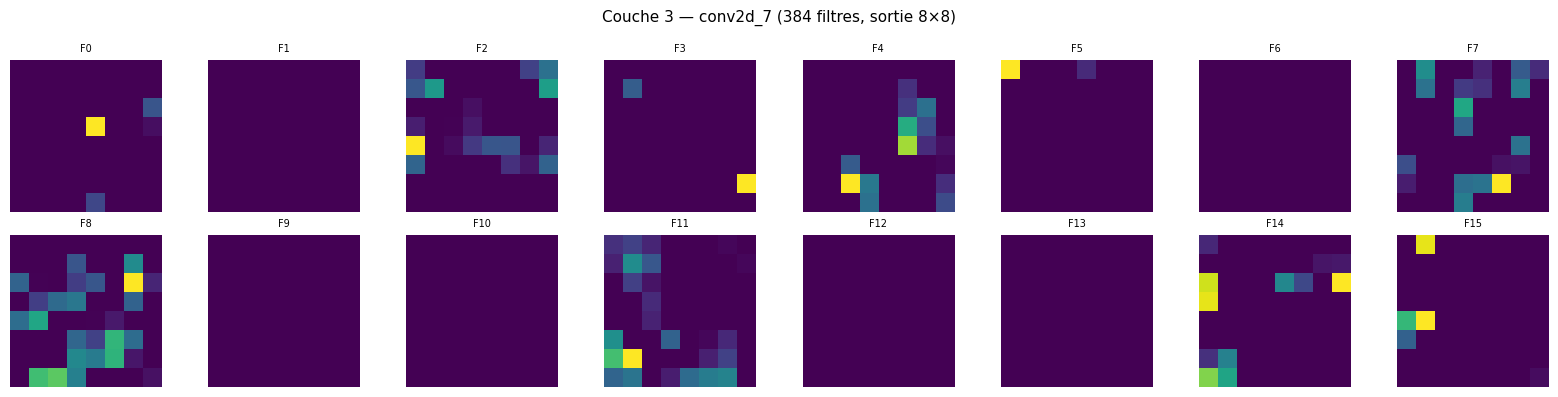

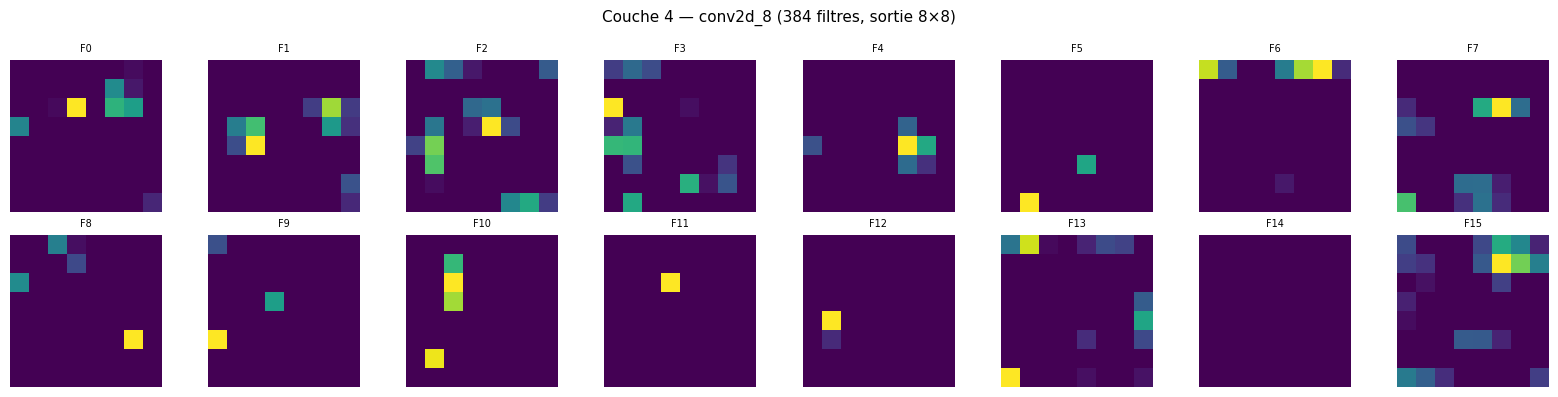

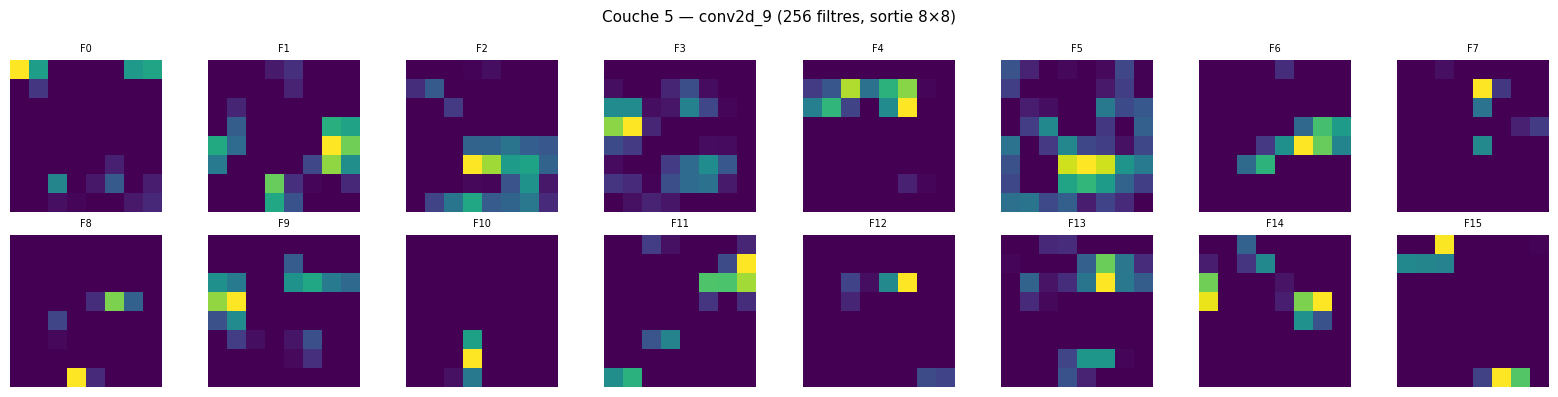

In [35]:
def show_feature_maps(image, model, max_filters=16):
    # Récupérer toutes les sorties des couches Conv2D
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]
    
    # Construire un modèle multi-sorties
    activation_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[l.output for l in conv_layers]
    )
    
    image_batch = tf.expand_dims(tf.cast(image, tf.float32), axis=0)
    activations = activation_model.predict(image_batch, verbose=0)
    
    for layer_idx, (layer, activation) in enumerate(zip(conv_layers, activations)):
        n_filters = min(activation.shape[-1], max_filters)
        
        fig, axes = plt.subplots(2, n_filters // 2, figsize=(n_filters, 4))
        fig.suptitle(
            f'Couche {layer_idx+1} — {layer.name} '
            f'({layer.filters} filtres, sortie {activation.shape[1]}×{activation.shape[2]})',
            fontsize=11
        )
        
        for i, ax in enumerate(axes.flat):
            if i < n_filters:
                feature_map = activation[0, :, :, i]
                # Normaliser entre 0 et 1 pour l'affichage
                f_min, f_max = feature_map.min(), feature_map.max()
                if f_max > f_min:
                    feature_map = (feature_map - f_min) / (f_max - f_min)
                ax.imshow(feature_map, cmap='viridis')
                ax.set_title(f'F{i}', fontsize=7)
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()

# Lancer sur une image de test
image = test_images[0]
true_label = class_names[int(test_labels[0])]
print(f"Image : {true_label}")
plt.imshow(image)
plt.axis('off')
plt.show()

show_feature_maps(image, model)

  iter   0 — score 'cat': -3.188
  iter  50 — score 'cat': 206.876
  iter 100 — score 'cat': 233.962
  iter 150 — score 'cat': 240.744


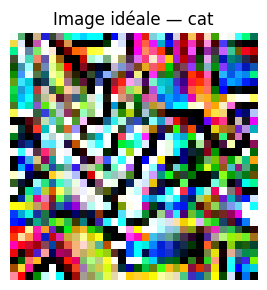


Couche 1 — conv2d_5 (96 filtres) — top 8 activés sur 'cat idéal'
  Scores : ['F44=1.03', 'F52=0.73', 'F12=0.61', 'F32=0.51', 'F81=0.48', 'F58=0.43', 'F4=0.26', 'F11=0.24']


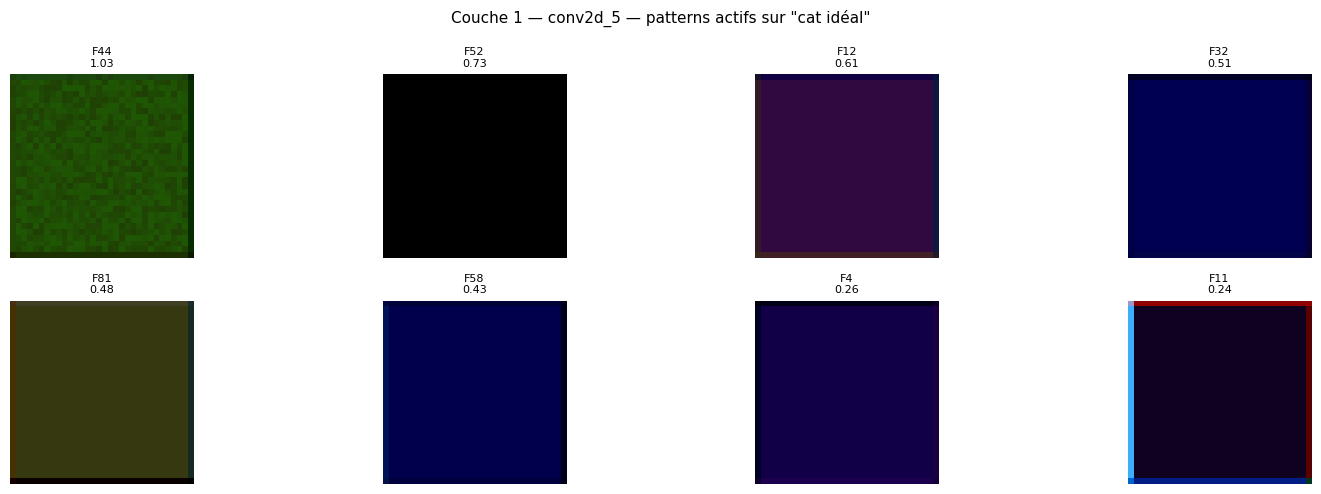


Couche 2 — conv2d_6 (256 filtres) — top 8 activés sur 'cat idéal'
  Scores : ['F77=50.74', 'F161=20.89', 'F62=19.72', 'F26=18.02', 'F41=14.45', 'F116=13.71', 'F205=12.81', 'F80=12.16']


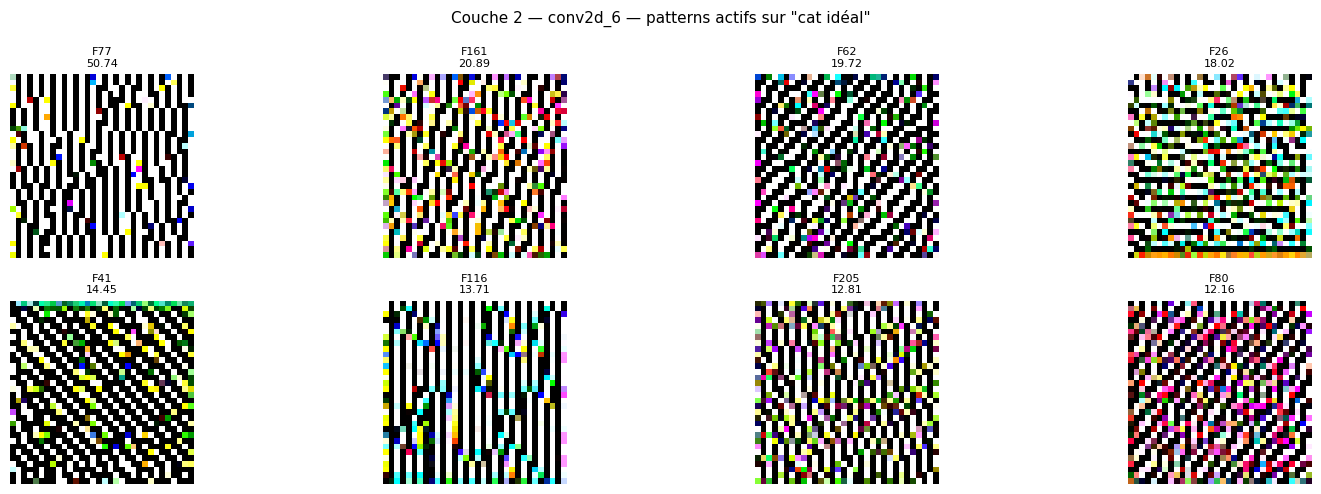


Couche 3 — conv2d_7 (384 filtres) — top 8 activés sur 'cat idéal'
  Scores : ['F78=91.10', 'F123=48.10', 'F110=45.77', 'F313=43.44', 'F230=41.60', 'F54=39.89', 'F188=39.57', 'F317=35.88']


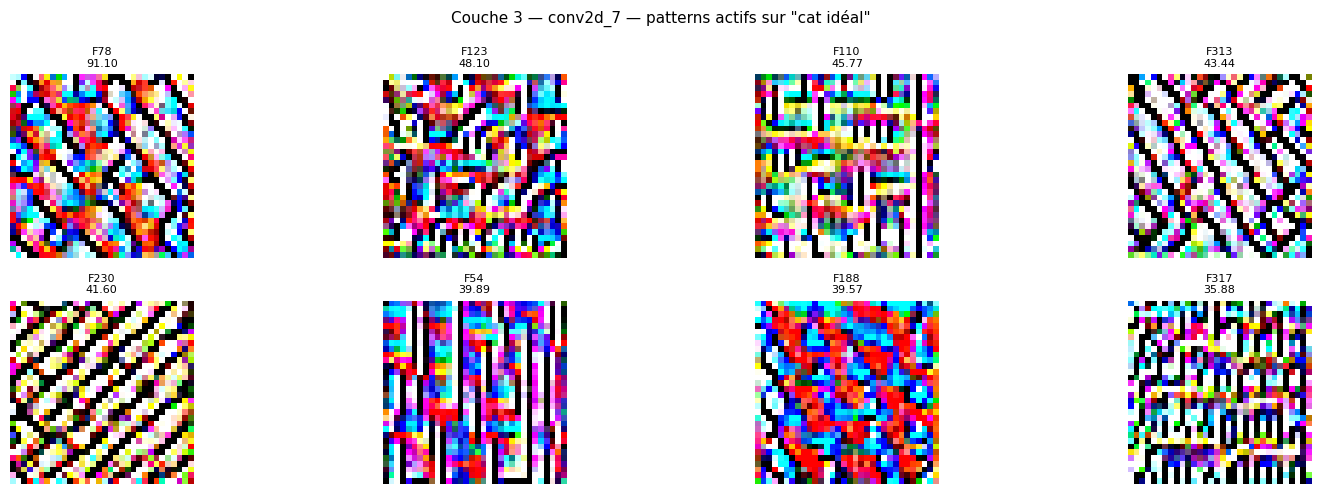


Couche 4 — conv2d_8 (384 filtres) — top 8 activés sur 'cat idéal'
  Scores : ['F252=26.84', 'F34=23.39', 'F77=20.62', 'F64=20.52', 'F28=20.25', 'F274=19.08', 'F363=18.82', 'F70=18.57']


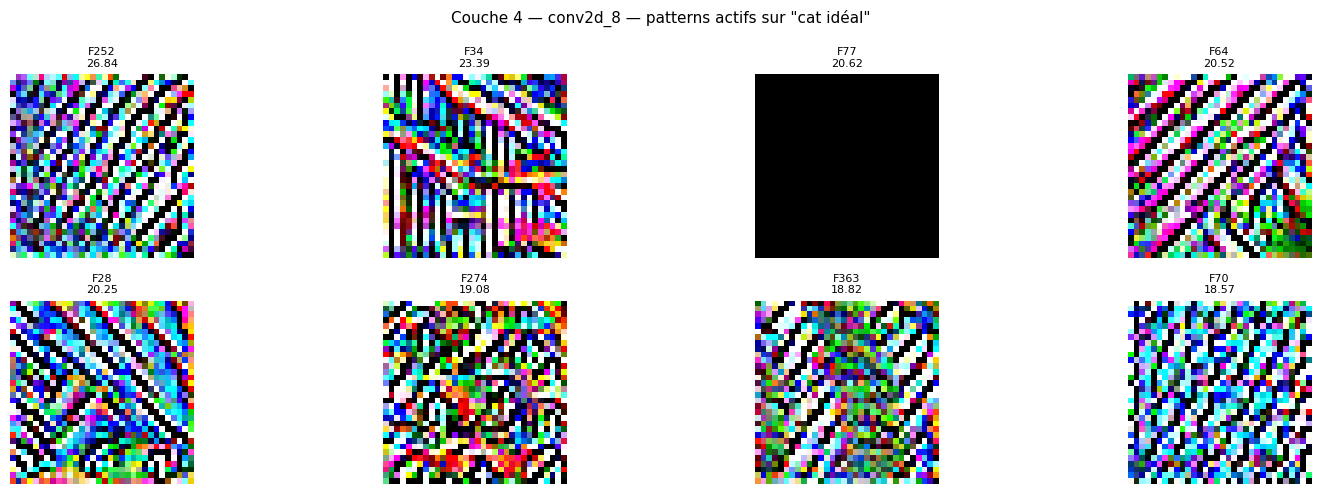


Couche 5 — conv2d_9 (256 filtres) — top 8 activés sur 'cat idéal'
  Scores : ['F3=80.77', 'F174=79.05', 'F74=54.32', 'F85=54.07', 'F118=52.38', 'F83=52.07', 'F223=50.90', 'F167=50.32']


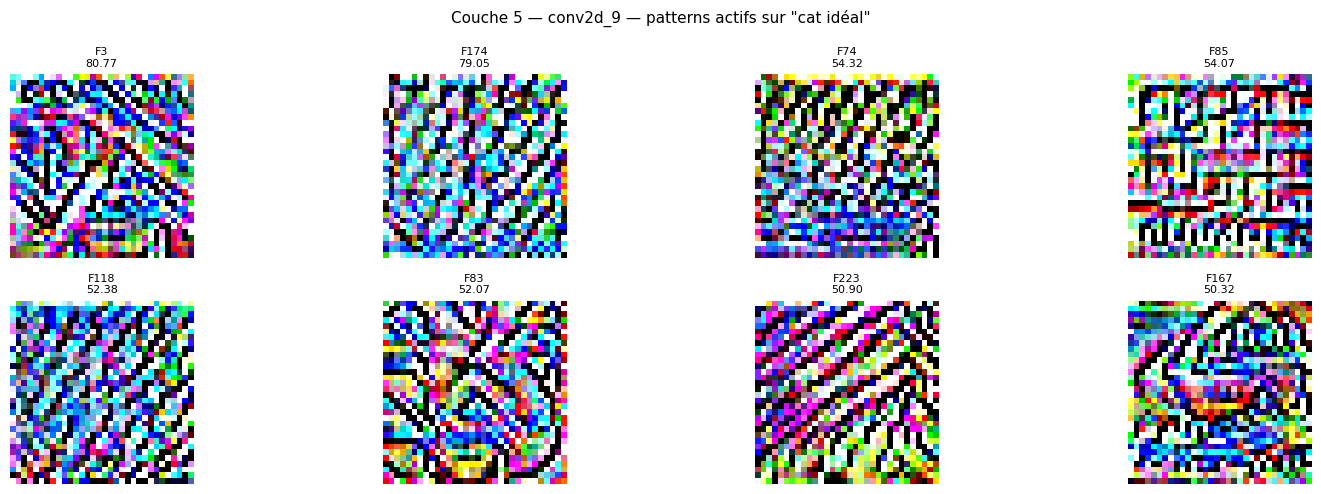

In [39]:
def visualize_class_with_activations(model, class_index, class_name,
                                      iterations=200, learning_rate=10.0, l2_reg=0.01,
                                      top_k=8, filter_iterations=150):
    
    # ── Étape 1 : Gradient ascent pour générer l'image idéale ──────────────
    image = tf.Variable(
        tf.random.uniform((1, 32, 32, 3), minval=0.4, maxval=0.6)
    )

    for i in range(iterations):
        with tf.GradientTape() as tape:
            predictions = model(image, training=False)
            loss = predictions[0, class_index] - l2_reg * tf.reduce_sum(image ** 2)
        grads = tape.gradient(loss, image)
        grads = grads / (tf.norm(grads) + 1e-8)
        image.assign_add(learning_rate * grads)
        image.assign(tf.clip_by_value(image, 0.0, 1.0))
        if i % 50 == 0:
            print(f"  iter {i:3d} — score '{class_name}': "
                  f"{predictions[0, class_index].numpy():.3f}")

    ideal_image = image[0].numpy()

    # Afficher l'image idéale
    plt.figure(figsize=(3, 3))
    plt.imshow(ideal_image)
    plt.title(f'Image idéale — {class_name}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # ── Étape 2 : Activer le modèle multi-sorties sur l'image idéale ────────
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]

    inp = tf.keras.Input(shape=(32, 32, 3))
    x = inp
    conv_outputs = []
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_outputs.append(x)
    activation_model = tf.keras.Model(inputs=inp, outputs=conv_outputs)

    image_batch = tf.expand_dims(tf.cast(ideal_image, tf.float32), axis=0)
    activations = activation_model.predict(image_batch, verbose=0)

    # ── Étape 3 : Pour chaque couche, top-k filtres + visualisation ─────────
    for layer_idx, (layer, activation) in enumerate(zip(conv_layers, activations)):
        filter_scores = activation[0].mean(axis=(0, 1))
        top_indices = filter_scores.argsort()[::-1][:top_k]

        print(f"\nCouche {layer_idx+1} — {layer.name} "
              f"({layer.filters} filtres) — top {top_k} activés sur '{class_name} idéal'")
        print(f"  Scores : {[f'F{i}={filter_scores[i]:.2f}' for i in top_indices]}")

        # Feature extractor jusqu'à cette couche
        inp2 = tf.keras.Input(shape=(32, 32, 3))
        x2 = inp2
        for layer2 in model.layers:
            x2 = layer2(x2)
            if layer2.name == layer.name:
                break
        feature_extractor = tf.keras.Model(inputs=inp2, outputs=x2)

        fig, axes = plt.subplots(2, top_k // 2, figsize=(top_k * 2, 5))
        fig.suptitle(
            f'Couche {layer_idx+1} — {layer.name} — '
            f'patterns actifs sur "{class_name} idéal"',
            fontsize=11
        )

        for ax, filter_idx in zip(axes.flat, top_indices):
            img_opt = tf.Variable(
                tf.random.uniform((1, 32, 32, 3), minval=0.4, maxval=0.6)
            )
            for _ in range(filter_iterations):
                with tf.GradientTape() as tape:
                    act = feature_extractor(img_opt, training=False)
                    loss = tf.reduce_mean(act[:, :, :, filter_idx])
                    loss -= 0.01 * tf.reduce_sum(img_opt ** 2)
                grads = tape.gradient(loss, img_opt)
                grads = grads / (tf.norm(grads) + 1e-8)
                img_opt.assign_add(learning_rate * grads)
                img_opt.assign(tf.clip_by_value(img_opt, 0.0, 1.0))

            ax.imshow(img_opt[0].numpy())
            ax.set_title(f'F{filter_idx}\n{filter_scores[filter_idx]:.2f}', fontsize=8)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

    return ideal_image


# Lancer sur le chat
ideal_cat = visualize_class_with_activations(
    model,
    class_index=3,
    class_name='cat',
    iterations=200,
    learning_rate=10.0,
    l2_reg=0.01,
    top_k=8,
    filter_iterations=150
)

Couches Conv2D disponibles : ['conv2d_5', 'conv2d_6', 'conv2d_7', 'conv2d_8', 'conv2d_9']


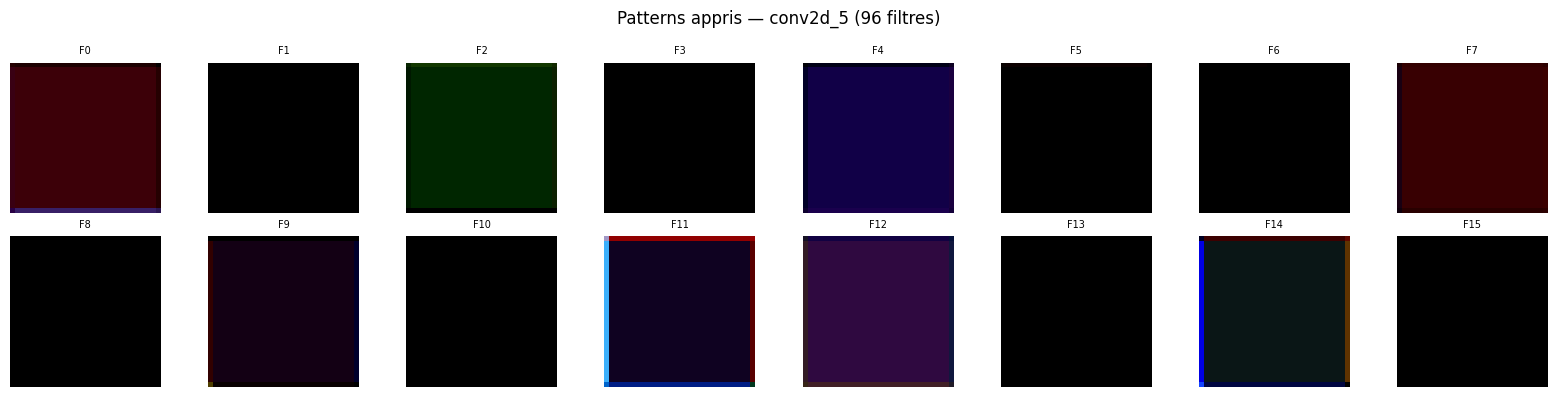

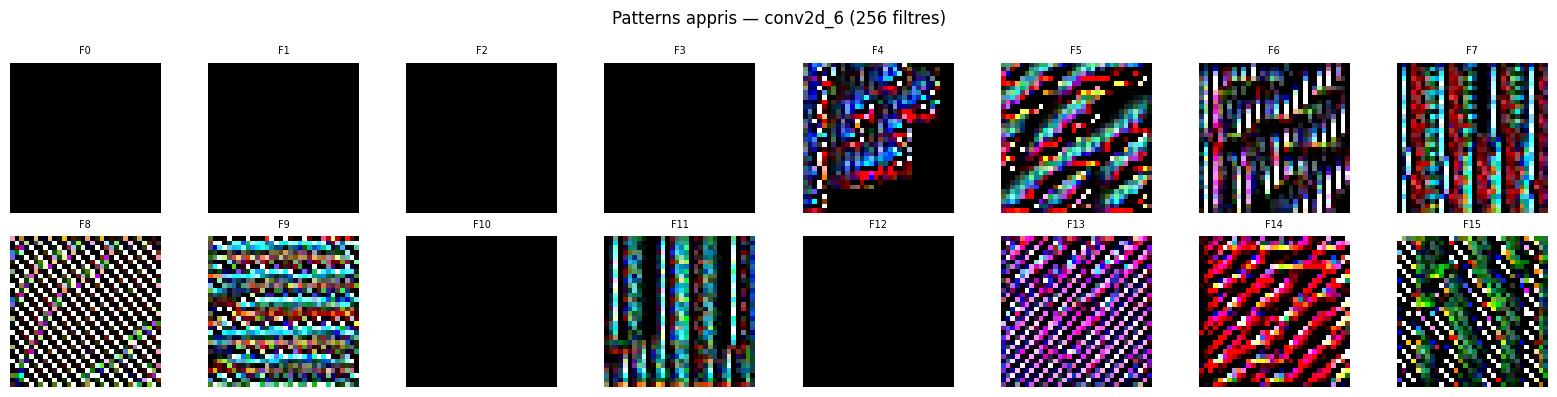

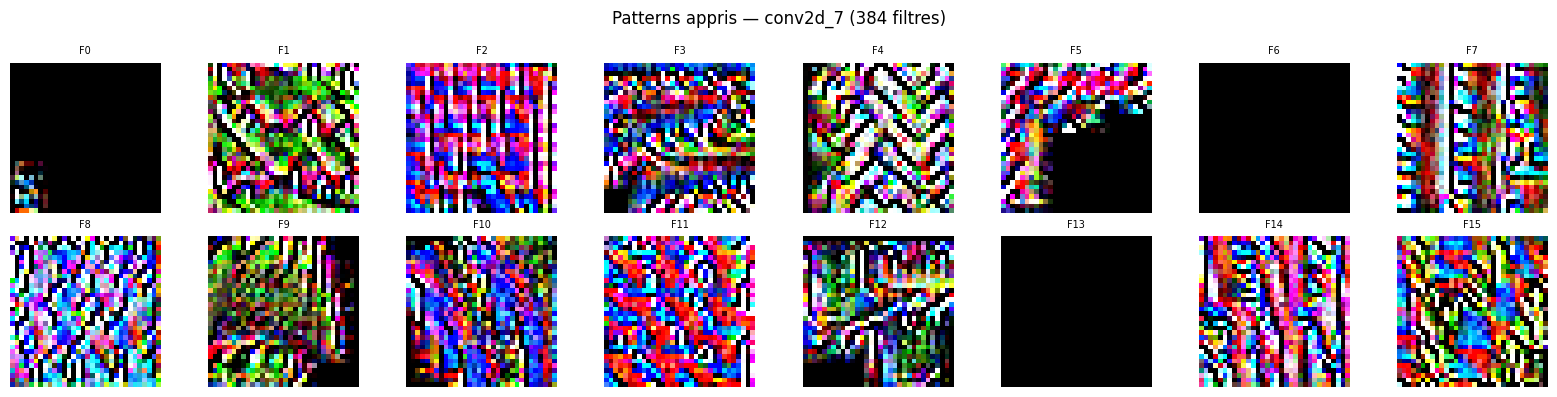

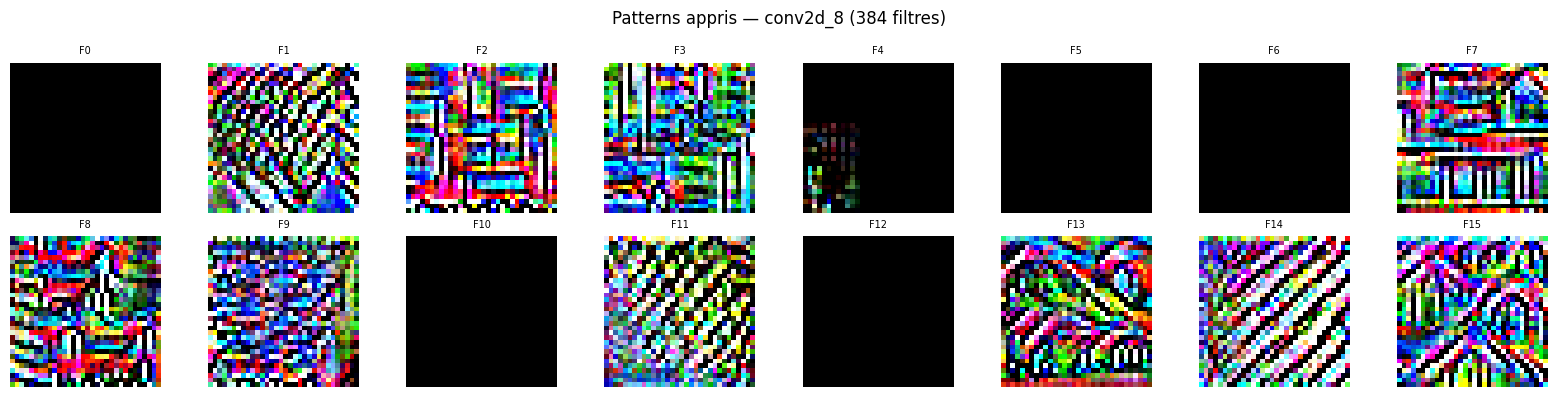

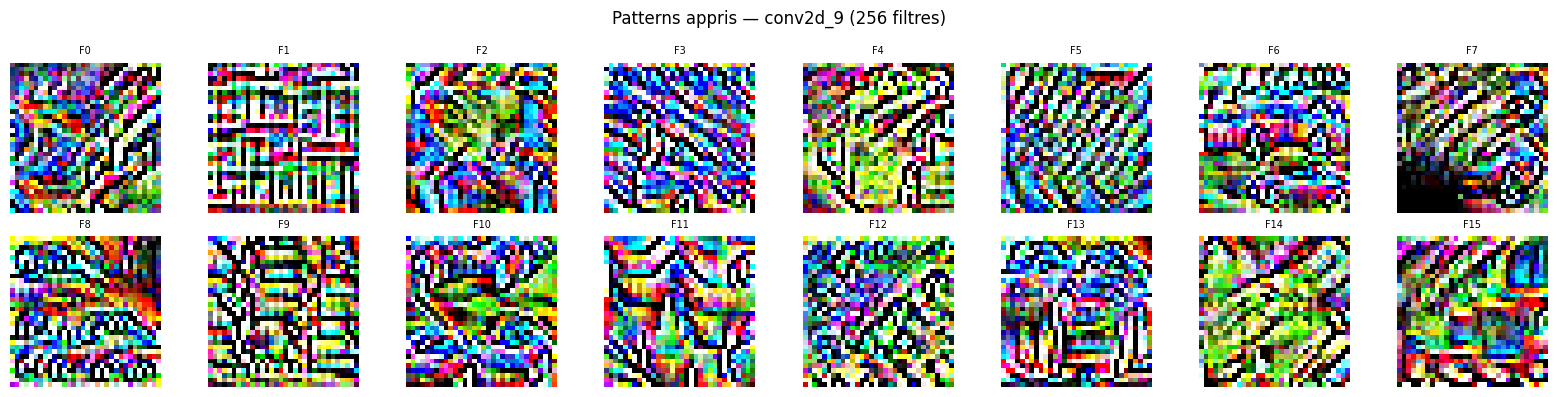

In [37]:
def visualize_filter(model, layer_name, filter_index,
                     iterations=200, learning_rate=10.0, l2_reg=0.01):
    
    # Sous-modèle qui sort l'activation de la couche cible
    feature_extractor = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer(layer_name).output
    )
    
    image = tf.Variable(
        tf.random.uniform((1, 32, 32, 3), minval=0.4, maxval=0.6)
    )

    for _ in range(iterations):
        with tf.GradientTape() as tape:
            activation = feature_extractor(image, training=False)
            # Maximiser la moyenne d'activation du filtre n°filter_index
            loss = tf.reduce_mean(activation[:, :, :, filter_index])
            loss -= l2_reg * tf.reduce_sum(image ** 2)
        
        grads = tape.gradient(loss, image)
        grads = grads / (tf.norm(grads) + 1e-8)
        image.assign_add(learning_rate * grads)
        image.assign(tf.clip_by_value(image, 0.0, 1.0))

    return image[0].numpy()


def show_layer_filters(model, layer_name, n_filters=16,
                       iterations=200, learning_rate=10.0):
    
    # Récupérer le nombre de filtres de la couche
    layer = model.get_layer(layer_name)
    total_filters = layer.filters
    n_filters = min(n_filters, total_filters)
    
    cols = 8
    rows = n_filters // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    fig.suptitle(f'Patterns appris — {layer_name} ({total_filters} filtres)', fontsize=12)
    
    for i, ax in enumerate(axes.flat):
        print(f"  Filtre {i+1}/{n_filters}", end='\r')
        img = visualize_filter(model, layer_name, i,
                               iterations=iterations,
                               learning_rate=learning_rate)
        ax.imshow(img)
        ax.set_title(f'F{i}', fontsize=7)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    print()


# Récupérer les noms des couches Conv2D
conv_layer_names = [l.name for l in model.layers 
                    if isinstance(l, tf.keras.layers.Conv2D)]
print("Couches Conv2D disponibles :", conv_layer_names)

# Visualiser 16 filtres par couche
for layer_name in conv_layer_names:
    show_layer_filters(model, layer_name, n_filters=16, iterations=200)

/tmp/ipykernel_3381/1585239510.py:84: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cat_indices = [i for i, l in enumerate(test_labels) if int(l) == cat_class_index]


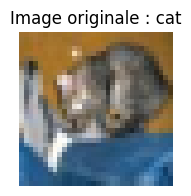


Couche 1 — conv2d_5 (96 filtres) — top 8 filtres activés par 'cat'
  Scores d'activation : ['F44=0.94', 'F52=0.67', 'F12=0.56', 'F32=0.47', 'F81=0.45', 'F58=0.39', 'F4=0.23', 'F11=0.20']


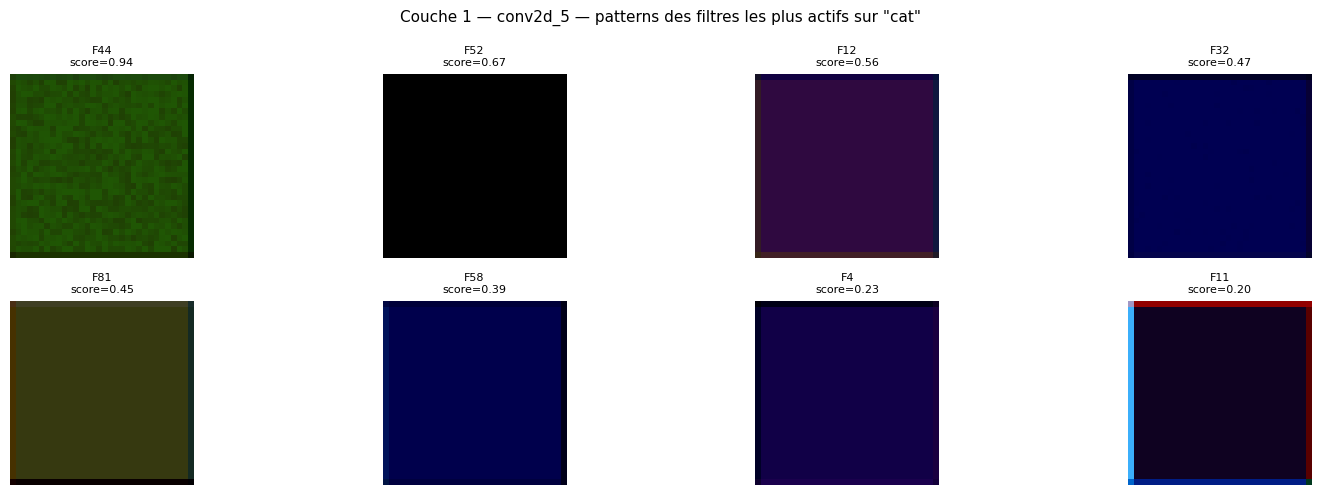


Couche 2 — conv2d_6 (256 filtres) — top 8 filtres activés par 'cat'
  Scores d'activation : ['F77=14.57', 'F116=7.54', 'F161=7.52', 'F80=5.14', 'F26=5.08', 'F170=4.90', 'F231=4.30', 'F62=4.20']


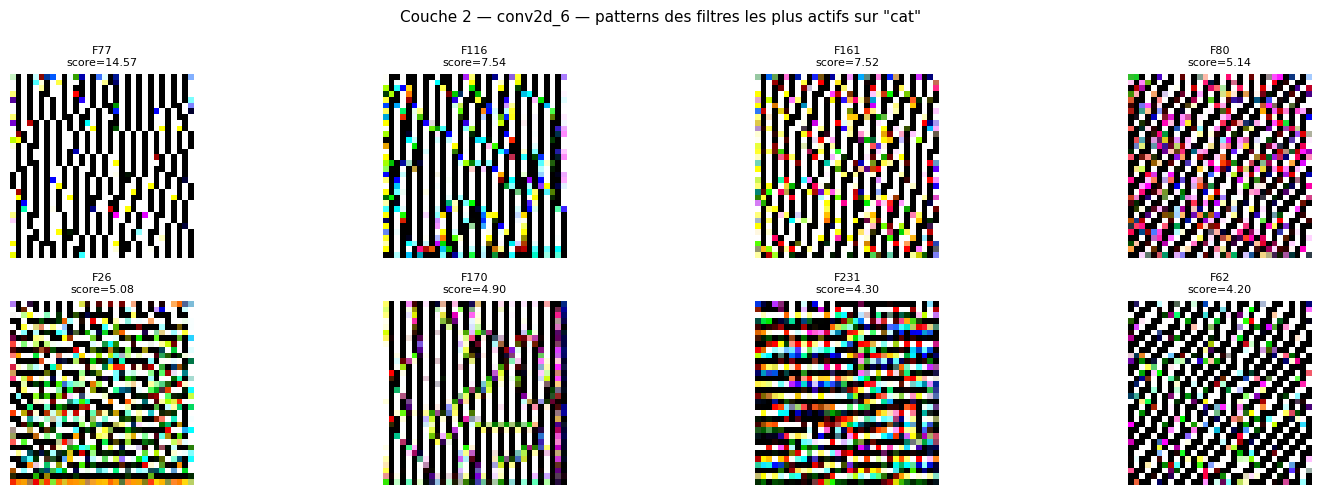


Couche 3 — conv2d_7 (384 filtres) — top 8 filtres activés par 'cat'
  Scores d'activation : ['F78=23.39', 'F54=19.65', 'F123=15.72', 'F110=14.08', 'F274=10.67', 'F188=10.51', 'F362=10.34', 'F291=9.10']


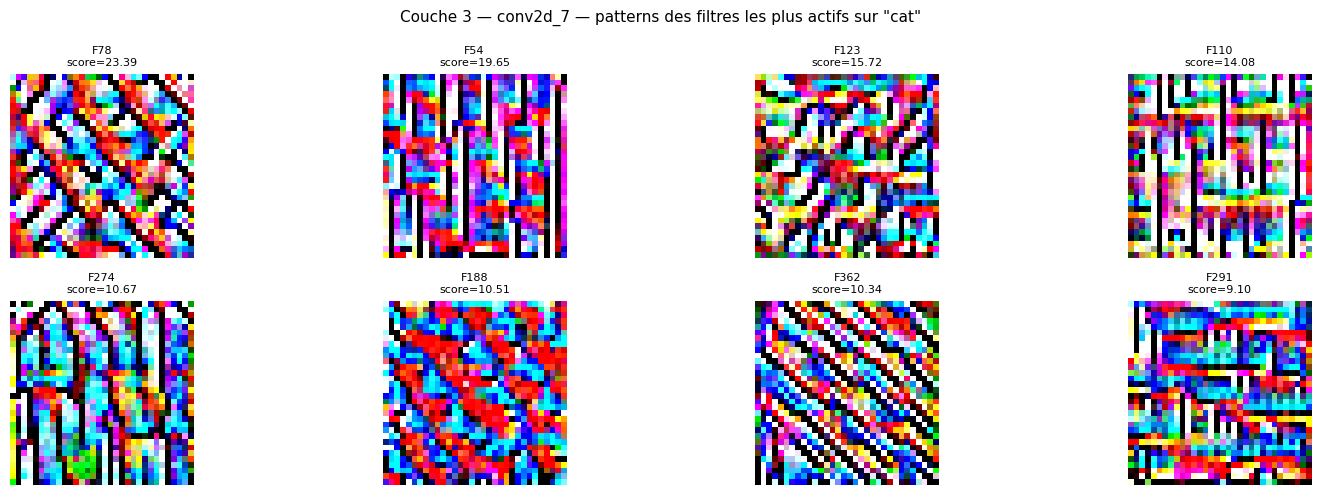


Couche 4 — conv2d_8 (384 filtres) — top 8 filtres activés par 'cat'
  Scores d'activation : ['F34=4.31', 'F305=3.63', 'F101=3.31', 'F308=3.21', 'F255=3.19', 'F148=3.16', 'F244=3.10', 'F318=3.07']


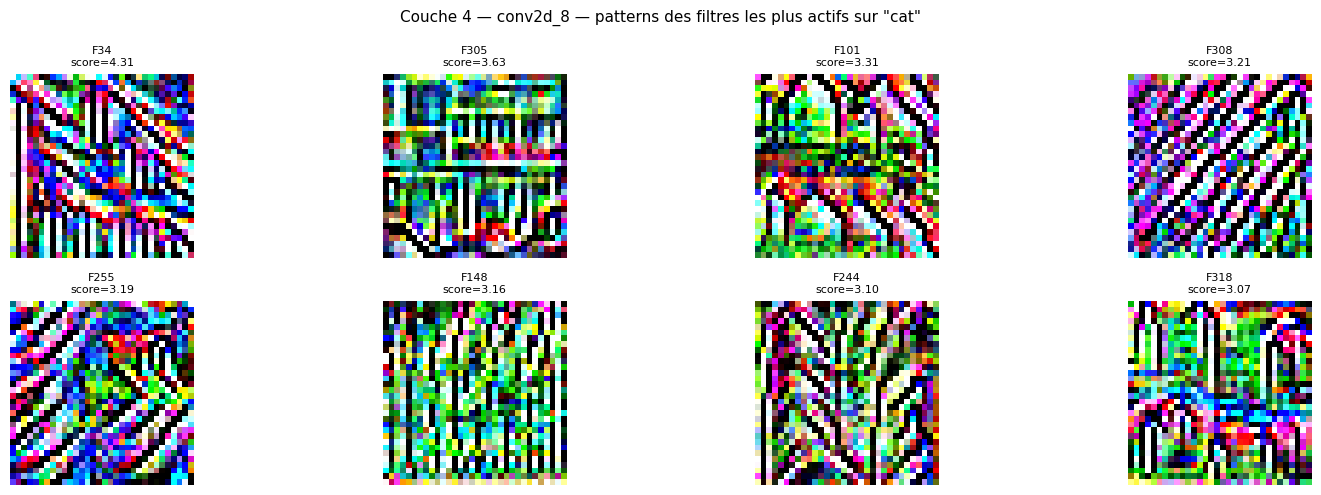


Couche 5 — conv2d_9 (256 filtres) — top 8 filtres activés par 'cat'
  Scores d'activation : ['F174=6.24', 'F5=5.95', 'F117=5.79', 'F60=5.02', 'F213=4.98', 'F223=4.82', 'F158=4.77', 'F173=4.58']


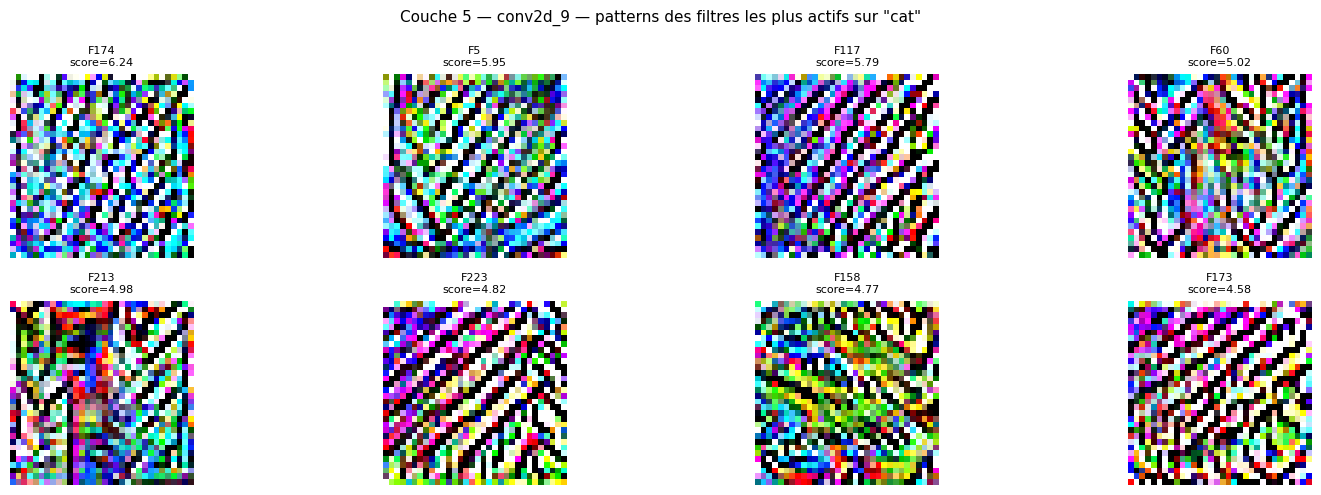

In [38]:
def show_most_activated_filters(model, image, class_name, top_k=8, iterations=150, learning_rate=10.0):
    """
    1. Passe l'image dans le réseau
    2. Pour chaque couche Conv2D, identifie les top_k filtres les plus activés
    3. Visualise le pattern appris par chacun de ces filtres
    """
    
    # Construire un modèle multi-sorties pour toutes les Conv2D
    conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]
    
    inp = tf.keras.Input(shape=(32, 32, 3))
    x = inp
    conv_outputs = []
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_outputs.append(x)
    activation_model = tf.keras.Model(inputs=inp, outputs=conv_outputs)
    
    # Passer l'image réelle et récupérer les activations
    image_batch = tf.expand_dims(tf.cast(image, tf.float32), axis=0)
    activations = activation_model.predict(image_batch, verbose=0)
    
    # Afficher l'image originale
    plt.figure(figsize=(2, 2))
    plt.imshow(image)
    plt.title(f'Image originale : {class_name}')
    plt.axis('off')
    plt.show()
    
    for layer_idx, (layer, activation) in enumerate(zip(conv_layers, activations)):
        # Moyenne spatiale de chaque filtre → score d'activation par filtre
        filter_scores = activation[0].mean(axis=(0, 1))  # shape: (n_filters,)
        
        # Top-k filtres les plus activés
        top_indices = filter_scores.argsort()[::-1][:top_k]
        
        print(f"\nCouche {layer_idx+1} — {layer.name} "
              f"({layer.filters} filtres) — top {top_k} filtres activés par '{class_name}'")
        print(f"  Scores d'activation : "
              f"{[f'F{i}={filter_scores[i]:.2f}' for i in top_indices]}")
        
        # Construire feature_extractor pour cette couche
        inp2 = tf.keras.Input(shape=(32, 32, 3))
        x2 = inp2
        for layer2 in model.layers:
            x2 = layer2(x2)
            if layer2.name == layer.name:
                break
        feature_extractor = tf.keras.Model(inputs=inp2, outputs=x2)
        
        # Visualiser le pattern de chaque filtre top-k
        fig, axes = plt.subplots(2, top_k // 2, figsize=(top_k * 2, 5))
        fig.suptitle(
            f'Couche {layer_idx+1} — {layer.name} — '
            f'patterns des filtres les plus actifs sur "{class_name}"',
            fontsize=11
        )
        
        for ax, filter_idx in zip(axes.flat, top_indices):
            img_opt = tf.Variable(
                tf.random.uniform((1, 32, 32, 3), minval=0.4, maxval=0.6)
            )
            for _ in range(iterations):
                with tf.GradientTape() as tape:
                    act = feature_extractor(img_opt, training=False)
                    loss = tf.reduce_mean(act[:, :, :, filter_idx])
                    loss -= 0.01 * tf.reduce_sum(img_opt ** 2)
                grads = tape.gradient(loss, img_opt)
                grads = grads / (tf.norm(grads) + 1e-8)
                img_opt.assign_add(learning_rate * grads)
                img_opt.assign(tf.clip_by_value(img_opt, 0.0, 1.0))
            
            ax.imshow(img_opt[0].numpy())
            ax.set_title(f'F{filter_idx}\nscore={filter_scores[filter_idx]:.2f}', fontsize=8)
            ax.axis('off')
        
        plt.tight_layout()
        plt.show()


# Trouver une image de chat dans le test set
cat_class_index = 3
cat_indices = [i for i, l in enumerate(test_labels) if int(l) == cat_class_index]
cat_image = test_images[cat_indices[0]]

show_most_activated_filters(model, cat_image, class_name='cat', top_k=8, iterations=150)

## Conclusion

Dans ce notebook, j'ai mene une analyse d'interpretabilite complete du CNN en me concentrant sur la visualisation interne des couches de convolution.

J'ai observe les activations couche par couche sur une image reelle (chat), ce qui montre une progression classique:
- Les premieres couches detectent surtout des motifs simples (contrastes, bords, couleurs).
- Les couches intermediaires captent des textures et des orientations plus structurees.
- Les couches profondes representent des motifs plus abstraits, combines et plus selectifs pour la classe finale.

J'ai egalement visualise les patterns appris par les filtres (gradient ascent), puis compare:
- les filtres globalement appris dans chaque couche,
- les filtres les plus actives par une image reelle de chat,
- et les filtres les plus actives par une image ideale de la classe chat.

Cette comparaison montre que le reseau ne reconnait pas un objet comme une forme unique, mais comme une combinaison hierarchique de motifs. Elle met aussi en evidence que certains filtres contribuent peu (cartes quasi nulles), tandis que d'autres portent fortement la decision.

En resume, ce travail valide que la prediction du modele repose sur des representations progressives, de plus en plus abstraites, construites au fil des couches convolutionnelles.